# Redes Neuronales Recurrentes

En este notebook exploraremos distintas arquitecturas de redes neuronales aplicadas a datos del mundo real. Hasta ahora hemos trabajado siempre con el mismo tipo de modelo: el **Perceptrón Multicapa** (MLP), una red *feed-forward* de la que ya conocemos bien su estructura y funcionamiento.

![](https://www.researchgate.net/profile/Mohamed_Zahran6/publication/303875065/figure/fig4/AS:371118507610123@1465492955561/A-hypothetical-example-of-Multilayer-Perceptron-Network.png)

El MLP es un modelo poderoso y versátil, pero tiene una limitación importante: no está diseñado para capturar dependencias temporales en **datos secuenciales**, como series de precios financieros. En este notebook trabajaremos con el dataset `USD_RUB_Historical_Data.csv`, que contiene el historial del tipo de cambio **dólar estadounidense / rublo ruso (USD/RUB)**. Este tipo de datos, en el que cada observación depende de las anteriores, requiere una arquitectura diferente: las **Redes Neuronales Recurrentes** (RNN).


## Definición

En una red neuronal *feed forward* la información viaja en un único sentido: desde la capa de entrada hacia la salida, sin volver atrás. El `MLP` es el ejemplo por excelencia de este tipo. En cambio, una **red recurrente** añade conexiones hacia atrás entre las neuronas, permitiendo que la información de pasos anteriores influya en el procesamiento actual.

![](https://miro.medium.com/max/2544/1*aIT6tmnk3qHpStkOX3gGcQ.png)


La imagen anterior muestra la `RNN` más simple posible: una entrada, una neurona oculta y una salida. En un `MLP` estándar, la salida se calcula como:

$$ \mathbf{y} = \mathbf{W}_y \mathbf{h} = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}) $$

En una `RNN`, además de la entrada $\mathbf{x}_t$ del instante actual, se incorpora también el estado oculto del instante anterior $\mathbf{h}_{t-1}$, con su propia matriz de pesos:

$$ \mathbf{y}_t = \mathbf{W}_y \mathbf{h}_t = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}_t + \mathbf{W}_h \mathbf{h}_{t-1}) $$

En nuestro caso, el dataset USD/RUB está compuesto por una secuencia de precios diarios. Cada elemento $\mathbf{x}_t$ representa el precio (y otras características) del día $t$, y la red deberá aprender a utilizar el contexto de los días anteriores para predecir el valor del día siguiente.


## Tipos de RNNs


Las `RNN` abren un nuevo abanico de posibilidades según cómo configuremos las entradas y salidas:

![](https://i.stack.imgur.com/b4sus.jpg)

La configuración *one-to-one* equivale al `MLP` clásico. Las demás permiten trabajar con secuencias: *many-to-one* es ideal para predecir un único valor futuro a partir de una ventana de valores pasados (que es exactamente lo que haremos con el precio USD/RUB), mientras que *many-to-many* permite predecir varios pasos hacia el futuro de forma simultánea.


## Entrenando RNNs

El entrenamiento de las `RNN` sigue el mismo algoritmo que ya conocemos: **backpropagation**. La diferencia es que ahora los gradientes pueden fluir desde múltiples salidas a lo largo del tiempo, lo que se conoce como *backpropagation through time* (BPTT). Esto puede provocar problemas como el **desvanecimiento** o la **explosión del gradiente**, de los que hablaremos más adelante.

![](https://s3.ap-south-1.amazonaws.com/techleer/191.png)

En la práctica, frameworks como PyTorch ya manejan este proceso internamente, por lo que podemos entrenar una `RNN` con los mismos ingredientes que usamos para el `MLP`: un optimizador, una función de pérdida y el bucle de entrenamiento habitual.


## Predicción de series temporales

Ahora que ya tenemos la base teórica, vamos a aplicarla a un problema real. Trabajaremos con el dataset `USD_RUB_Historical_Data.csv`, que contiene precios históricos diarios del tipo de cambio dólar/rublo.Cargaremos los datos, los normalizaremos y construiremos ventanas deslizantes de `n_steps` días para predecir el precio del día siguiente.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(15, 8))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            if ix >= len(series):
                break
            s = series[ix, :, 0]
            plt.plot(s, ".-")
            if y is not None:
                plt.plot([len(s)], y[ix], "bx", markersize=10)
            if y_pred is not None:
                plt.plot([len(s)], y_pred[ix], "ro")
            plt.grid(True)
            plt.hlines(0, 0, len(s) + 2, linewidth=1)
            plt.ylim(s.min() - 0.05, s.max() + 0.05)
            if row == r - 1:
                plt.xlabel(x_label if x_label else "Paso de tiempo", fontsize=12)
            if col == 0:
                plt.ylabel(y_label if y_label else "Precio", fontsize=12, rotation=0, labelpad=40)

    legend_items = [Line2D([0], [0], color='steelblue', marker='.', linestyle='-', label='Historial de precios')]
    if y is not None:
        legend_items.append(Line2D([0], [0], color='blue', marker='x', linestyle='None', markersize=10, label='Precio real del día siguiente'))
    if y_pred is not None:
        legend_items.append(Line2D([0], [0], color='red', marker='o', linestyle='None', markersize=6, label='Predicción del modelo'))
    fig.legend(handles=legend_items, loc='lower center', ncol=len(legend_items), fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.01))

    plt.suptitle("Ventanas de series temporales — USD/RUB", fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


In [2]:
def plot_series_forecast(series, y=None, y_pred=None, y_pred_std=None, x_label="$t$", y_label="$x$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=False, sharex=True, figsize=(20, 10))  # sharey=False
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row*c
            if ix >= len(series):
                break
            s = series[ix, :, 0]
            plt.plot(s, ".-", linewidth=2, markersize=6)
            
            all_vals = list(s)  # colectar todos los valores para ylim
            
            if y is not None:
                y_plot = np.atleast_1d(y[ix])
                all_vals.extend(y_plot)
                plt.plot(range(len(s), len(s) + len(y_plot)), y_plot, "bx", markersize=10, linewidth=2)
            if y_pred is not None:
                y_p = np.atleast_1d(y_pred[ix])
                all_vals.extend(y_p)
                plt.plot(range(len(s), len(s) + len(y_p)), y_p, "ro", markersize=8, linewidth=2)
            if y_pred_std is not None:
                y_p = np.atleast_1d(y_pred[ix])
                y_s = np.atleast_1d(y_pred_std[ix])
                plt.plot(range(len(s), len(s) + len(y_p)), y_p + y_s, "--", alpha=0.5)
                plt.plot(range(len(s), len(s) + len(y_p)), y_p - y_s, "--", alpha=0.5)
                all_vals.extend(y_p + y_s)
                all_vals.extend(y_p - y_s)
            margin = (max(all_vals) - min(all_vals)) * 0.15
            plt.ylim(min(all_vals) - margin, max(all_vals) + margin)
            plt.grid(True, alpha=0.3)
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=14)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=14, rotation=0, labelpad=30)
    plt.tight_layout()
    plt.show()

---

### Dataset real: USD/RUB

Una vez visto el ejemplo con datos sintéticos, replicamos el mismo flujo pero ahora con el dataset `USD_RUB_Historical_Data.csv`. Las series ya no son señales sinusoidales controladas, sino el precio histórico real del tipo de cambio dólar/rublo, lo que introduce mayor irregularidad y ruido real de mercado.


In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('USD_RUB_Historical_Data.csv')
df = df.drop(columns=['Vol.'])

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")


        Date   Price     Open     High      Low  Change %
0 2007-01-01  26.305  26.3255  26.3255  26.3095     -0.06
1 2007-01-02  26.305  26.3100  26.3100  26.3095      0.00
2 2007-01-03  26.305  26.3100  26.3100  26.3095      0.00
3 2007-01-04  26.382  26.3100  26.3965  26.3083      0.29
4 2007-01-05  26.382  26.3845  26.3845  26.3845      0.00

Shape: (5014, 6)

Columnas: ['Date', 'Price', 'Open', 'High', 'Low', 'Change %']


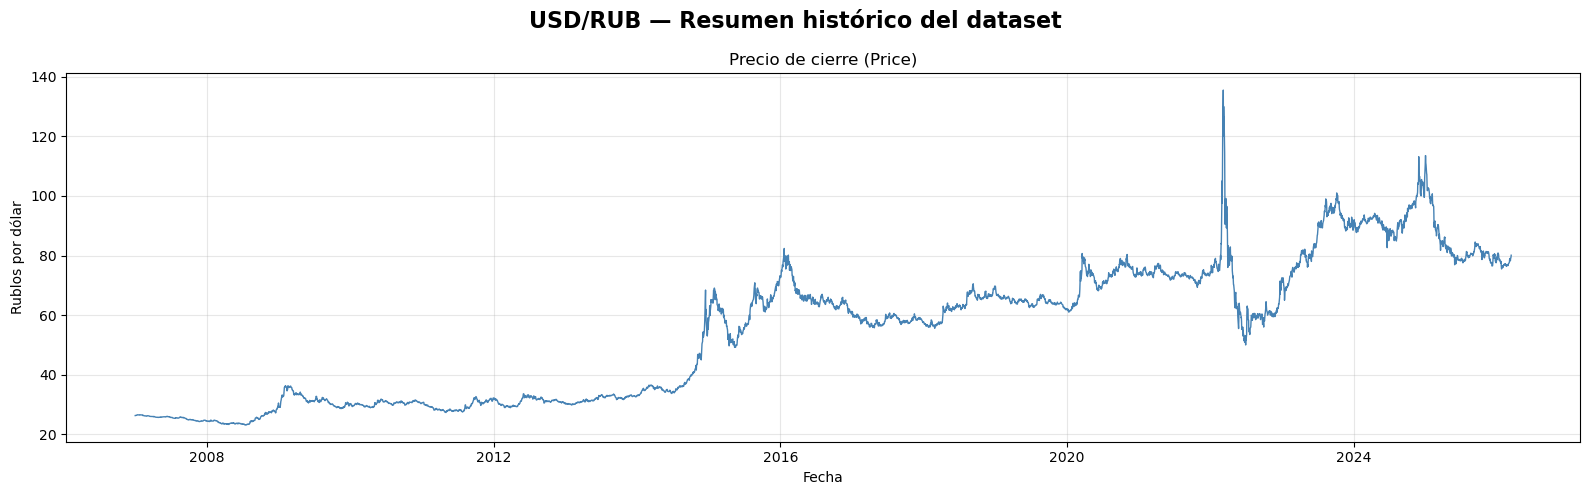

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
fig.suptitle('USD/RUB — Resumen histórico del dataset', fontsize=16, fontweight='bold')

ax.plot(df['Date'], df['Price'], color='steelblue', linewidth=1)
ax.set_title('Precio de cierre (Price)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Rublos por dólar')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
scaler = MinMaxScaler()
features = ['Price','Open','High','Low','Change %']
data = scaler.fit_transform(df[features])

n_steps = 30

def create_sequences(data, n_steps, target_idx=0):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps, target_idx])
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32).reshape(-1, 1))

sequences, targets = create_sequences(data, n_steps)

n = len(sequences)
n_train = int(0.7 * n)
n_valid = int(0.2 * n)

X_train, y_train = sequences[:n_train],               targets[:n_train]
X_valid, y_valid = sequences[n_train:n_train+n_valid], targets[n_train:n_train+n_valid]
X_test,  y_test  = sequences[n_train+n_valid:],        targets[n_train+n_valid:]

print(f"Train: {X_train.shape},  {y_train.shape}")
print(f"Valid: {X_valid.shape},  {y_valid.shape}")
print(f"Test:  {X_test.shape},   {y_test.shape}")


Train: (3488, 30, 5),  (3488, 1)
Valid: (996, 30, 5),  (996, 1)
Test:  (500, 30, 5),   (500, 1)


In [6]:
print(df.describe())


                                Date        Price         Open         High  \
count                           5014  5014.000000  5014.000000  5014.000000   
mean   2016-08-07 06:21:06.533705728    54.617623    54.724883    55.312535   
min              2007-01-01 00:00:00    23.153100    23.157400    23.203500   
25%              2011-10-20 06:00:00    31.060350    31.052500    31.211225   
50%              2016-08-09 12:00:00    59.343000    59.564350    60.427200   
75%              2021-05-24 18:00:00    73.080000    73.267800    73.788275   
max              2026-03-13 00:00:00   135.500000   135.500000   158.300000   
std                              NaN    22.729827    22.824575    23.310682   

               Low     Change %  
count  5014.000000  5014.000000  
mean     54.183935     0.029962  
min      23.055000   -13.540000  
25%      30.923425    -0.420000  
50%      58.954800     0.000000  
75%      72.776700     0.450000  
max     125.500000    20.430000  
std      22.3896

Nuestro objetivo es **predecir el precio de cierre del día siguiente** a partir de los `n_steps` días anteriores. Si un modelo logra hacer esto con precisión, podría ser útil como señal en estrategias de análisis financiero o para monitorear la volatilidad del tipo de cambio USD/RUB.


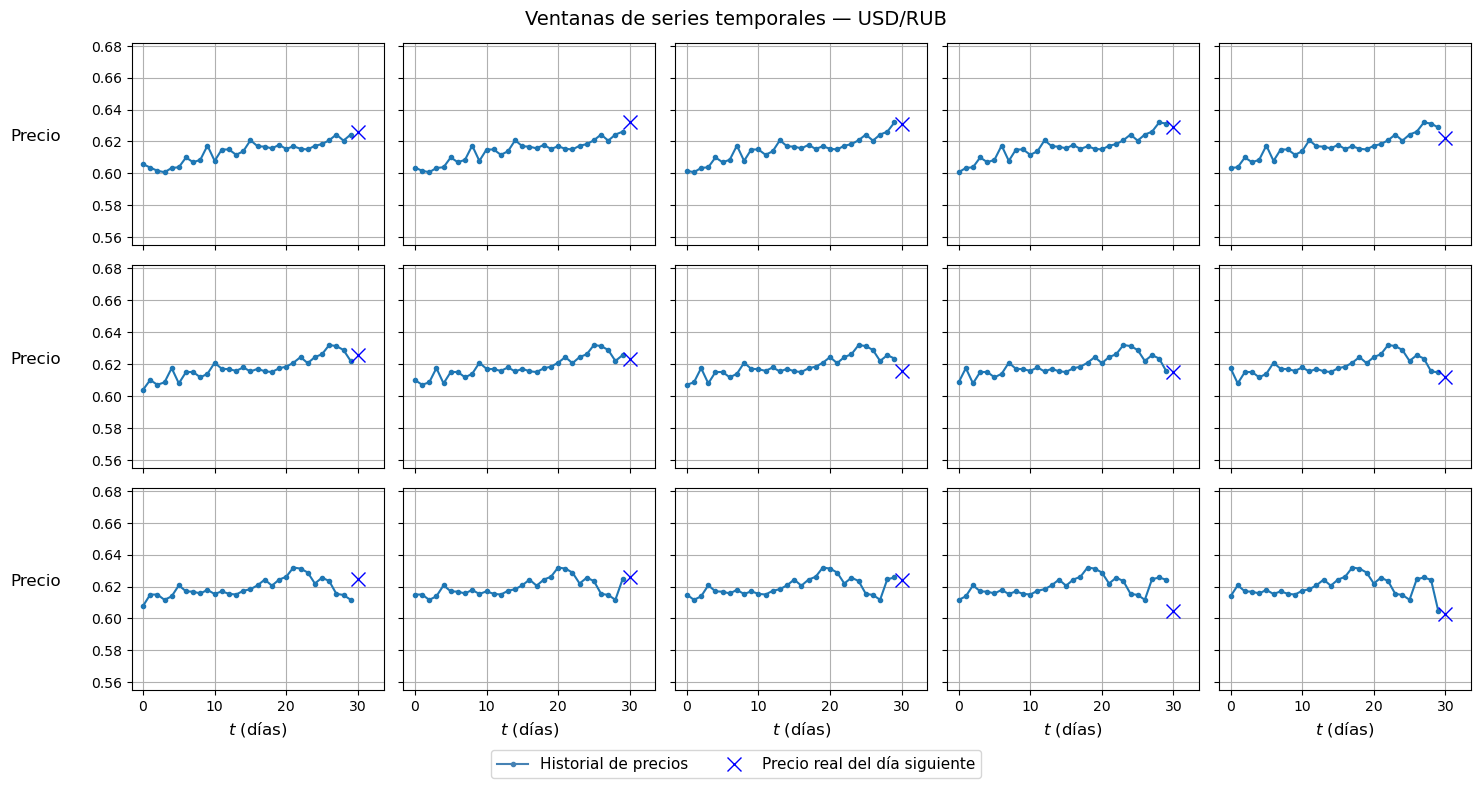

In [7]:
# Visualizar 15 ventanas del conjunto de prueba USD/RUB con su valor objetivo (cruz azul)
# El eje Y muestra el precio normalizado [0, 1]; la 'x' azul es el precio real del día siguiente
plot_series(X_test, y_test, x_label="$t$ (días)", y_label="Precio")


### Predicción *Naive*

Un modelo de referencia muy sencillo consiste en predecir que el precio del día siguiente será igual al precio del último día conocido. A pesar de su simplicidad, este modelo puede ser difícil de superar en series financieras con poca volatilidad a corto plazo.


In [8]:
from sklearn.metrics import mean_squared_error

# Predicción naive: el precio del día siguiente = último precio conocido de la ventana
y_pred_naive = X_test[:, -1, 0].reshape(-1, 1)
mean_squared_error(y_test, y_pred_naive)


0.0001012635839288123

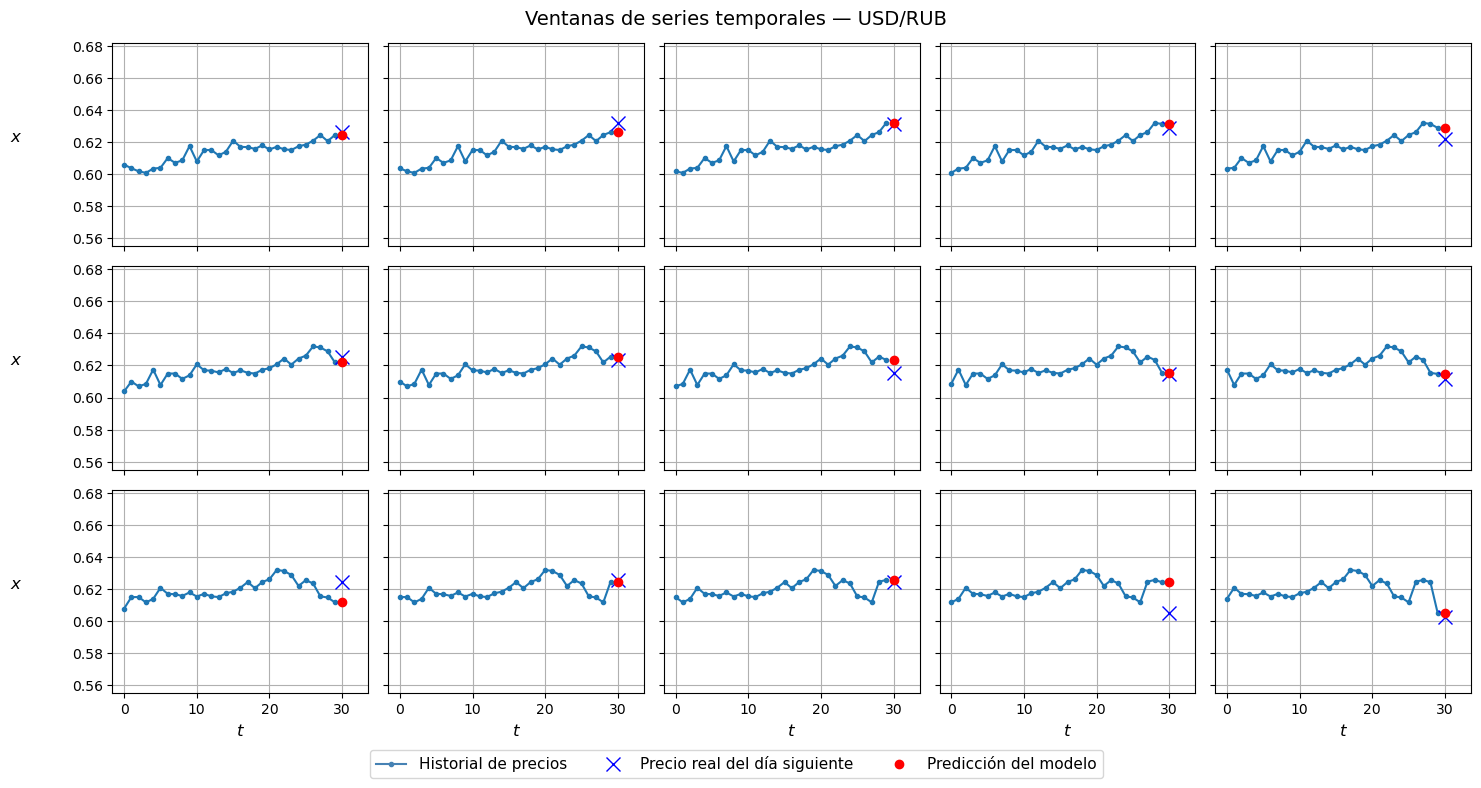

In [9]:
plot_series(X_test, y_test, y_pred_naive)


Como se puede ver, este modelo tan simple tiene un rendimiento razonable: en series financieras, el precio del día anterior suele ser una buena estimación del precio del día siguiente. Este resultado es el **umbral mínimo** que cualquier modelo más complejo debería superar.


### Perceptrón Multicapa

Dado que todas las ventanas tienen la misma longitud (`n_steps`), podemos intentar resolver el problema con un `MLP` estándar. Aunque no captura dependencias temporales de forma explícita, puede aprender correlaciones lineales útiles si los patrones son suficientemente regulares.


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
  def __init__(self, X, y=None, train=True):
    self.X = X
    self.y = y
    self.train = train

  def __len__(self):
    return len(self.X)

  def __getitem__(self, ix):
    if self.train:
      return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
    return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval': TimeSeriesDataset(X_valid, y_valid),
    'test': TimeSeriesDataset(X_test, y_test, train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=False, batch_size=64),
    'eval': DataLoader(dataset['eval'], shuffle=False, batch_size=64),
    'test': DataLoader(dataset['test'], shuffle=False, batch_size=64)
}

In [11]:
class MLP(torch.nn.Module):
  def __init__(self, n_steps=30, n_features=5, n_out=1):
    super().__init__()
    
    self.fc = torch.nn.Sequential(
        torch.nn.Linear(n_steps * n_features, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, n_out),
    )

  def forward(self, x):
    x = x.view(x.shape[0], -1)
    x = self.fc(x)
    return x

mlp = MLP(n_steps=n_steps, n_features=X_train.shape[2])
mlp

MLP(
  (fc): Sequential(
    (0): Linear(in_features=150, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [12]:
from tqdm import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"

def fit(model, dataloader, epochs=250, early_stopping=20):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6, verbose=True)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    best_loss, step = float('inf'), 0
    
    for epoch in bar:
        model.train()
        train_loss, train_acc = [], []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            train_acc.append((torch.abs(y_hat - y) < 0.10).float().mean().item())
        
        model.eval()
        eval_loss, eval_acc = [], []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
                eval_acc.append((torch.abs(y_hat - y) < 0.10).float().mean().item())
        
        mean_train_loss = np.mean(train_loss)
        mean_eval_loss = np.mean(eval_loss)
        mean_train_acc = np.mean(train_acc)
        mean_eval_acc = np.mean(eval_acc)
        bar.set_description(f"loss {mean_train_loss:.5f} val_loss {mean_eval_loss:.5f} acc {mean_train_acc:.5f} val_acc {mean_eval_acc:.5f}")
        
        scheduler.step(mean_eval_loss)
        
        if mean_eval_loss < best_loss:
            best_loss = mean_eval_loss
            step = 0
        else:
            step += 1
        
        if early_stopping and step > early_stopping:
            break

def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

In [13]:
fit(mlp, dataloader, epochs=100, early_stopping=15)

d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
loss 0.00016 val_loss 0.00118 acc 1.00000 val_acc 0.97949: 100%|██████████| 100/100 [00:13<00:00,  7.47it/s]


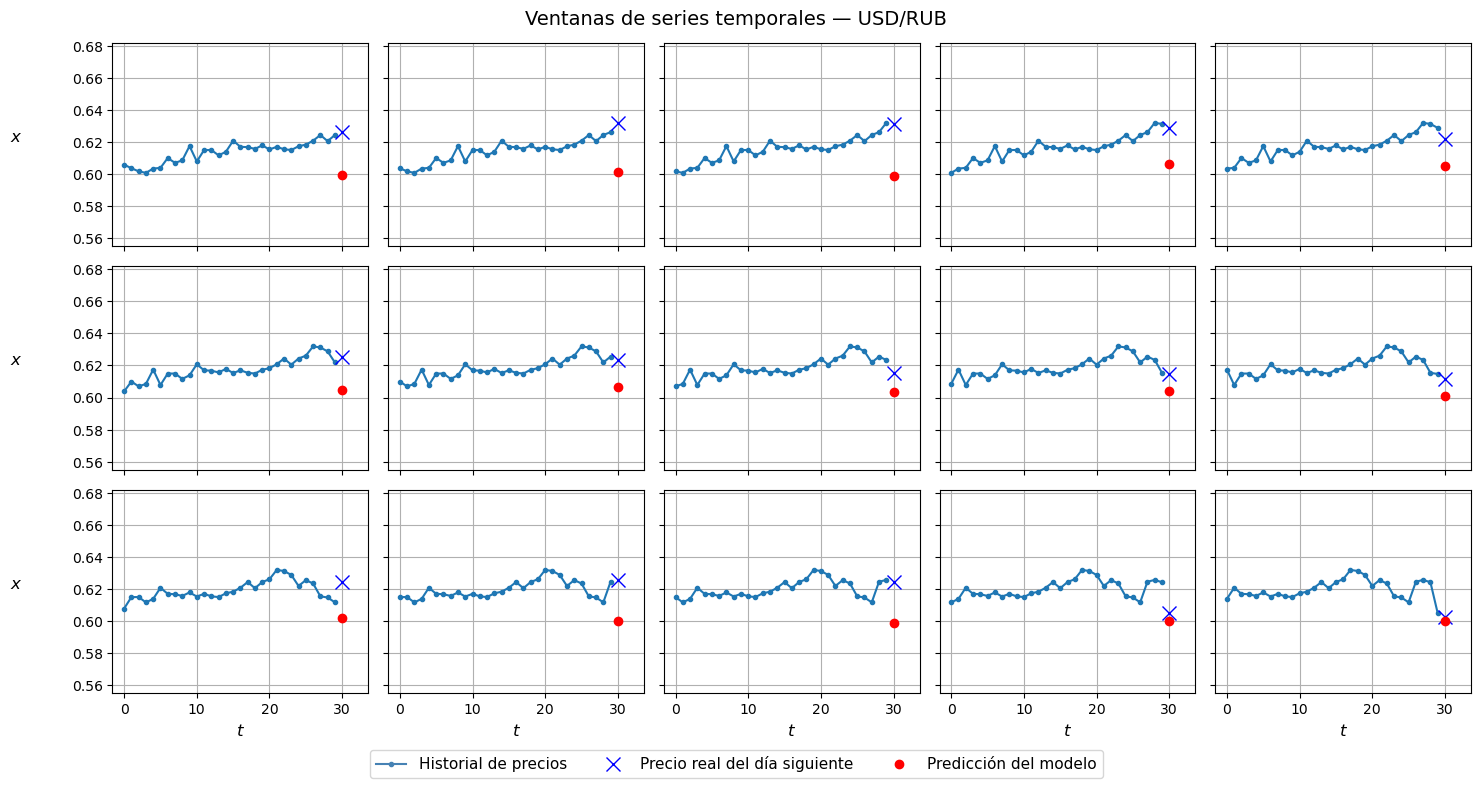

0.000569281168282032

In [14]:
y_pred = predict(mlp, dataloader['test'])
plot_series(X_test, y_test, y_pred.cpu().numpy())
mean_squared_error(y_test, y_pred.cpu().numpy())


El `MLP` logra mejorar (o al menos igualar) la predicción ingenua. Este modelo es más práctico para **pronóstico autoregresivo**, donde cada predicción se usa como entrada para el siguiente día, permitiendo proyectar indefinidamente hacia el futuro.

## Pronóstico Futuro: Predicción Autoregresiva

Implementamos un enfoque **many-to-one autoregresivo**, este diseño es más práctico para **predecir valores futuros** porque permite generar pronósticos a cualquier horizonte mediante iteración: cada predicción se usa como entrada para el siguiente día, sin limitarse a los datos conocidos del dataset.

In [15]:
horizon = 30

last_window = data[-n_steps:].astype(np.float32).copy()
future_scaled = []

mlp.eval()
for _ in range(horizon):
    x_in = torch.from_numpy(last_window).unsqueeze(0).to(device=device, dtype=torch.float32)
    
    with torch.no_grad():
        next_scaled = mlp(x_in).item()
    
    next_scaled = float(np.clip(next_scaled, 0.0, 1.0))
    future_scaled.append(next_scaled)
    
    new_row = last_window[-1].copy().reshape(1, -1)
    new_row[0, 0] = next_scaled
    last_window = np.concatenate([last_window[1:], new_row], axis=0).astype(np.float32)

price_min = scaler.data_min_[0]
price_range = scaler.data_range_[0]
future_prices = np.array(future_scaled) * price_range + price_min

today = pd.Timestamp('2026-03-13')
future_dates = pd.date_range(start=today + pd.Timedelta(days=1), periods=horizon, freq='D')

future_df = pd.DataFrame({
    'Date': future_dates,
    'Prediccion_USD_RUB': future_prices,
})

print(f"PRONÓSTICO A {horizon} DÍAS - MODELO MLP")
print(future_df)
print(f"\nÚltimo precio histórico (13 de marzo 2026): {df['Price'].iloc[-1]:.4f} RUB/USD")
print(f"Precio predicho día {horizon}: {future_df['Prediccion_USD_RUB'].iloc[-1]:.4f} RUB/USD")


PRONÓSTICO A 30 DÍAS - MODELO MLP
         Date  Prediccion_USD_RUB
0  2026-03-14           78.378595
1  2026-03-15           78.591674
2  2026-03-16           78.767361
3  2026-03-17           78.937643
4  2026-03-18           79.071538
5  2026-03-19           79.222126
6  2026-03-20           79.139533
7  2026-03-21           79.548703
8  2026-03-22           79.706403
9  2026-03-23           79.573239
10 2026-03-24           79.780365
11 2026-03-25           79.950326
12 2026-03-26           79.963176
13 2026-03-27           80.083136
14 2026-03-28           80.036904
15 2026-03-29           80.142787
16 2026-03-30           80.066207
17 2026-03-31           80.207916
18 2026-04-01           80.491817
19 2026-04-02           80.238144
20 2026-04-03           80.293898
21 2026-04-04           80.410268
22 2026-04-05           80.329135
23 2026-04-06           80.449924
24 2026-04-07           80.294708
25 2026-04-08           80.419723
26 2026-04-09           80.454491
27 2026-04-10 


Últimos 180 registros: desde 2025-07-07 hasta 2026-03-13


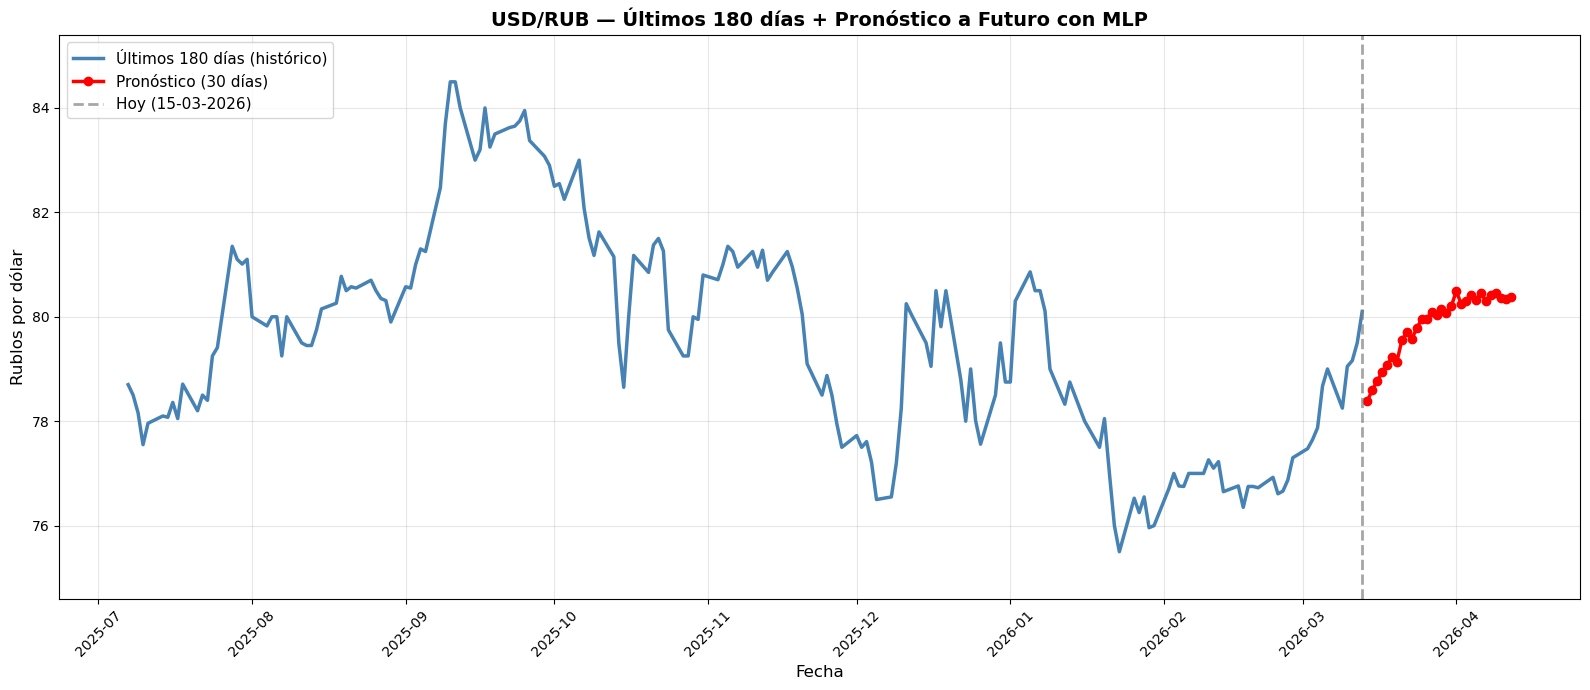

In [16]:
plt.figure(figsize=(16, 7))

today = pd.Timestamp('2026-03-13')

historical_recent = df.tail(180)

print(f"\nÚltimos 180 registros: desde {historical_recent['Date'].iloc[0].date()} hasta {historical_recent['Date'].iloc[-1].date()}")

plt.plot(historical_recent['Date'], historical_recent['Price'], linewidth=2.5, color='steelblue', label='Últimos 180 días (histórico)')

plt.plot(future_df['Date'], future_df['Prediccion_USD_RUB'], 'o-', 
         linewidth=2.5, color='red', markersize=6, label='Pronóstico (30 días)')

plt.axvline(today, color='gray', linestyle='--', alpha=0.7, linewidth=2, label='Hoy (15-03-2026)')

all_prices = np.concatenate([historical_recent['Price'].values, future_df['Prediccion_USD_RUB'].values])
y_min, y_max = all_prices.min(), all_prices.max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)

plt.title('USD/RUB — Últimos 180 días + Pronóstico a Futuro con MLP', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rublos por dólar', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
def create_sequences_local_norm(data_raw, n_steps, target_idx=0):
    X, y, scalers = [], [], []
    for i in range(len(data_raw) - n_steps):
        window = data_raw[i:i + n_steps]         # (30, 5)
        target = data_raw[i + n_steps, target_idx]
        
        sc = MinMaxScaler()
        window_norm = sc.fit_transform(window) 
        
        price_min  = sc.data_min_[target_idx]
        price_range = sc.data_range_[target_idx]
        target_norm = (target - price_min) / price_range if price_range > 0 else 0.0
        target_norm = float(np.clip(target_norm, 0.0, 1.0))
        
        X.append(window_norm.astype(np.float32))
        y.append(np.float32(target_norm))
        scalers.append(sc)                 
    
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32).reshape(-1, 1),
            scalers)

In [18]:
scaler_global = MinMaxScaler()
data_full = scaler_global.fit_transform(df[features])

sequences_ln, targets_ln, scalers_ln = create_sequences_local_norm(
    df[features].values,
    n_steps
)

n = len(sequences_ln)
n_train_ln = int(0.7 * n)
n_valid_ln = int(0.2 * n)

X_train_ln = sequences_ln[:n_train_ln]
y_train_ln = targets_ln[:n_train_ln]
X_valid_ln = sequences_ln[n_train_ln:n_train_ln+n_valid_ln]
y_valid_ln = targets_ln[n_train_ln:n_train_ln+n_valid_ln]
X_test_ln  = sequences_ln[n_train_ln+n_valid_ln:]
y_test_ln  = targets_ln[n_train_ln+n_valid_ln:]
scalers_test = scalers_ln[n_train_ln+n_valid_ln:]

print(f"Train: {X_train_ln.shape}, Valid: {X_valid_ln.shape}, Test: {X_test_ln.shape}")

Train: (3488, 30, 5), Valid: (996, 30, 5), Test: (500, 30, 5)


In [19]:
dataset_ln = {
    'train': TimeSeriesDataset(X_train_ln, y_train_ln),
    'eval':  TimeSeriesDataset(X_valid_ln, y_valid_ln),
    'test':  TimeSeriesDataset(X_test_ln,  y_test_ln, train=False)
}
dataloader_ln = {
    'train': DataLoader(dataset_ln['train'], shuffle=True,  batch_size=64),
    'eval':  DataLoader(dataset_ln['eval'],  shuffle=False, batch_size=64),
    'test':  DataLoader(dataset_ln['test'],  shuffle=False, batch_size=64)
}

## Red Neuronal Recurrente (RNN)

Hemos visto que el **MLP** es capaz de predecir el precio del siguiente día aprovechando todas las características de los últimos `n_steps` días. Sin embargo, el MLP procesa toda la secuencia de una vez, flattening todos los datos. Una **RNN**, en cambio, procesa la secuencia paso a paso, manteniendo el contexto temporal mediante su estado oculto recurrente. Esto la hace naturalmente más adecuada para datos secuenciales.

Veamos cómo implementar una **RNN simple** para la misma tarea y comparar su rendimiento con el MLP.

In [20]:
class RNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=5, hidden_size=40, num_layers=2, batch_first=True, dropout=0.1)
        self.fc = torch.nn.Linear(40, 1)

    def forward(self, x):
        x, h = self.rnn(x)
        y = self.fc(x[:, -1])
        return y

rnn = RNN()
rnn

RNN(
  (rnn): RNN(5, 40, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=40, out_features=1, bias=True)
)

In [21]:
fit(rnn, dataloader, epochs=200, early_stopping=50)

d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
loss 0.00051 val_loss 0.00182 acc 1.00000 val_acc 0.98730:  34%|███▎      | 67/200 [00:13<00:26,  4.94it/s]


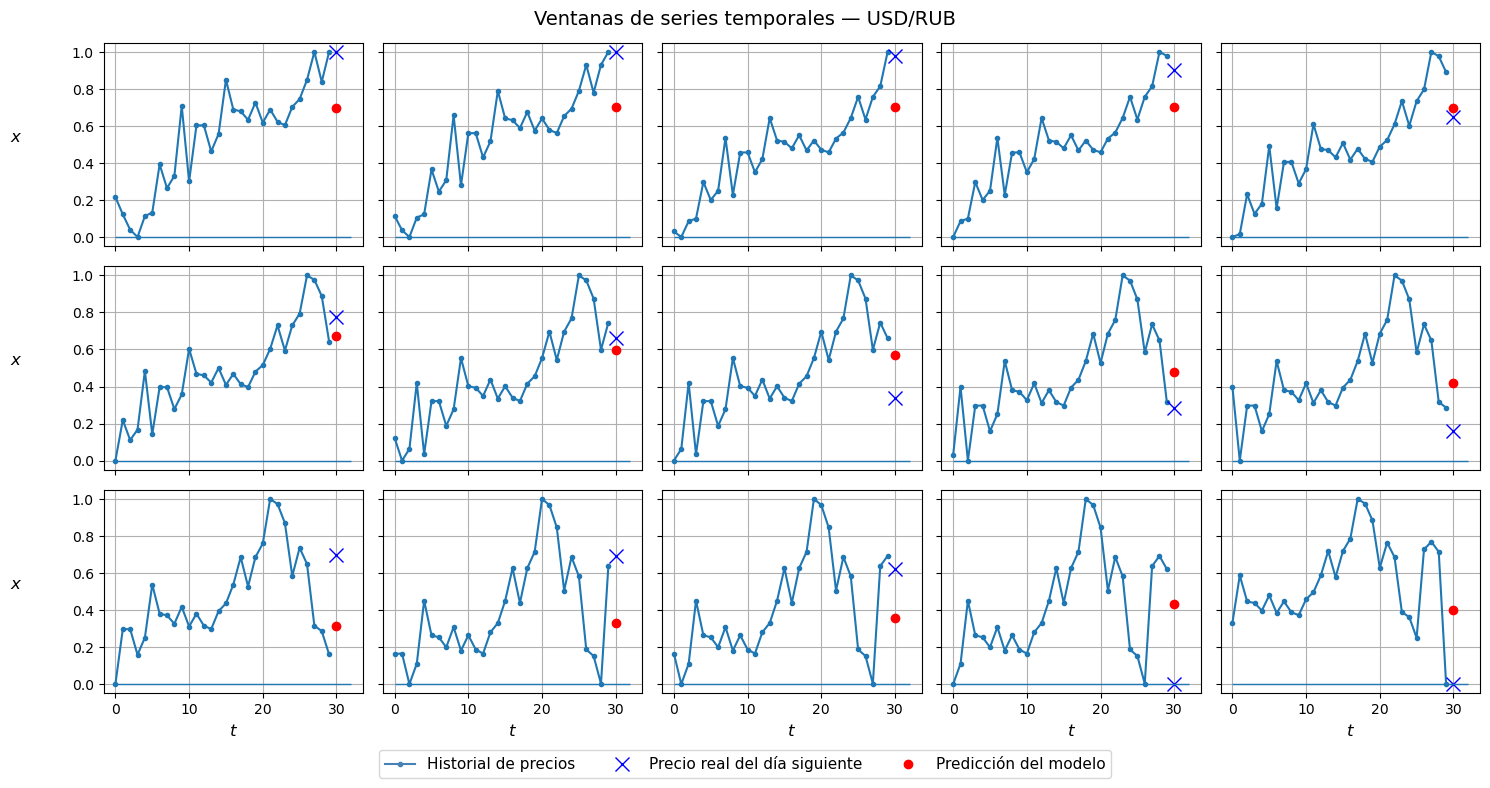

MSE: 0.04346843


In [22]:
y_pred_ln = predict(rnn, dataloader_ln['test']).cpu().numpy()
plot_series(X_test_ln, y_test_ln, y_pred_ln)
mse = mean_squared_error(y_test_ln, y_pred_ln)
print(f"MSE: {mse:.8f}")


## Predicción de Múltiples Pasos Futuros

Hasta ahora hemos predicho un único valor (el precio del día siguiente). Sin embargo, en aplicaciones prácticas nos interesa predecir **múltiples pasos al futuro**: el precio de los próximos 10 días, mes, etc.

Existen dos enfoques principales:
1. **Predicción autoregresiva iterativa**: Predecir un paso, usarlo como entrada para predecir el siguiente, y así sucesivamente.
2. **Predicción directa multi-paso**: Entrenar el modelo para predecir directamente todos los pasos futuros al mismo tiempo.

En esta sección exploraremos ambos enfoques utilizando el dataset USD/RUB.

### Preparación de datos para predicción multi-paso

In [23]:
horizon = 10 

def create_multi_step_sequences(data, n_steps, horizon, target_idx=0):
    X, y = [], []
    for i in range(len(data) - n_steps - horizon + 1):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps:i + n_steps + horizon, target_idx])
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32))

X_ms, y_ms = create_multi_step_sequences(data, n_steps, horizon, target_idx=0)

n = len(X_ms)
n_train_ms = int(0.7 * n)
n_valid_ms = int(0.2 * n)

X_train_ms = X_ms[:n_train_ms]
y_train_ms = y_ms[:n_train_ms]

X_valid_ms = X_ms[n_train_ms:n_train_ms + n_valid_ms]
y_valid_ms = y_ms[n_train_ms:n_train_ms + n_valid_ms]

X_test_ms = X_ms[n_train_ms + n_valid_ms:]
y_test_ms = y_ms[n_train_ms + n_valid_ms:]

print(f"Multi-step sequences:")
print(f"X_train: {X_train_ms.shape}, y_train: {y_train_ms.shape}")
print(f"X_valid: {X_valid_ms.shape}, y_valid: {y_valid_ms.shape}")
print(f"X_test:  {X_test_ms.shape},  y_test:  {y_test_ms.shape}")

Multi-step sequences:
X_train: (3482, 30, 5), y_train: (3482, 10)
X_valid: (995, 30, 5), y_valid: (995, 10)
X_test:  (498, 30, 5),  y_test:  (498, 10)


In [24]:
dataset_ms = {
    'train': TimeSeriesDataset(X_train_ms, y_train_ms),
    'eval': TimeSeriesDataset(X_valid_ms, y_valid_ms),
    'test': TimeSeriesDataset(X_test_ms, y_test_ms, train=False)
}

dataloader_ms = {
    'train': DataLoader(dataset_ms['train'], shuffle=False, batch_size=64),
    'eval': DataLoader(dataset_ms['eval'], shuffle=False, batch_size=64),
    'test': DataLoader(dataset_ms['test'], shuffle=False, batch_size=64)
}

### Enfoque 1: Predicción Directa Multi-Paso

Entrenaremos una **RNN profunda** (con múltiples capas) que predice directamente todos los `horizon` pasos futuros al mismo tiempo.

In [25]:
class DeepRNN(torch.nn.Module):
    def __init__(self, n_out=10, dropout=0, input_size=None, all_timesteps=False):
        super().__init__()
        if input_size is None:
            input_size = 1
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=64, num_layers=3, batch_first=True, dropout=dropout)
        self.fc = torch.nn.Linear(64, n_out)
        self.n_out = n_out
        self.all_timesteps = all_timesteps

    def forward(self, x):
        x, h = self.rnn(x)
        if self.all_timesteps:
            x_reshaped = x.contiguous().view(-1, x.size(-1))
            y = self.fc(x_reshaped)
            y = y.contiguous().view(x.size(0), -1, self.n_out)
        else:
            y = self.fc(h[-1])
        return y

rnn_multi = DeepRNN(n_out=horizon, input_size=X_train_ms.shape[2])
print("DeepRNN para predicción multi-paso:")
print(rnn_multi)

DeepRNN para predicción multi-paso:
DeepRNN(
  (rnn): RNN(5, 64, num_layers=3, batch_first=True)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


In [26]:
print("Entrenando DeepRNN para predicción multi-paso (10 días)...")
fit(rnn_multi, dataloader_ms, epochs=200, early_stopping=20)

d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Entrenando DeepRNN para predicción multi-paso (10 días)...


loss 0.00016 val_loss 0.00198 acc 0.99940 val_acc 0.98096: 100%|██████████| 200/200 [00:42<00:00,  4.68it/s]



Entrenando DeepRNN para predicción multi-paso (10 días)...


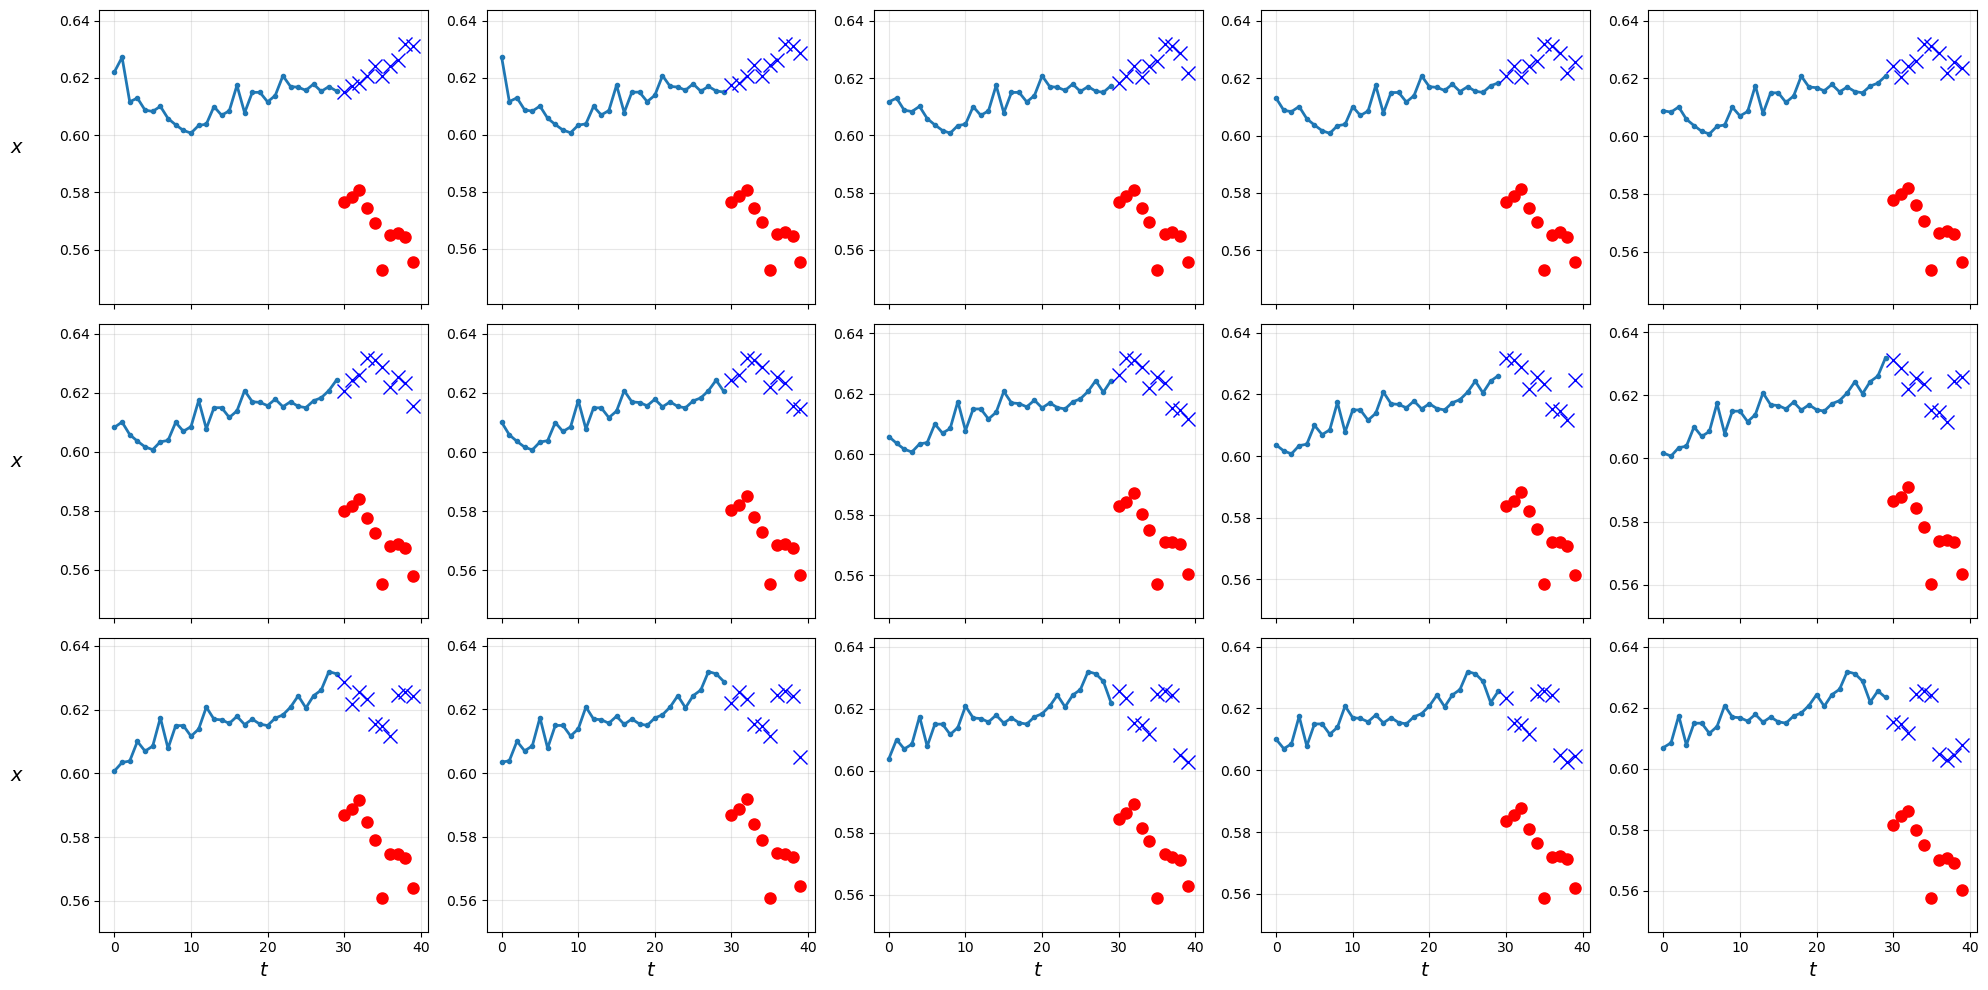

MSE Multi-paso: 0.00216025


In [27]:
print(f"\nEntrenando DeepRNN para predicción multi-paso (10 días)...")
y_pred_multi = predict(rnn_multi, dataloader_ms['test']).cpu().numpy()
plot_series_forecast(X_test_ms, y_test_ms, y_pred_multi)
mse_multi = mean_squared_error(y_test_ms, y_pred_multi)
print(f"MSE Multi-paso: {mse_multi:.8f}")

### Enfoque 2: Optimización en Todos los Timesteps

Existe un enfoque más sofisticado: igual que en el modelo anterior, predecimos múltiples pasos al futuro, pero ahora **optimizamos en todos los instantes temporales** de la secuencia de entrada, no solo en el último.

La ventaja es que recibimos más gradientes durante el backpropagation, lo que puede resultar en un entrenamiento más estable y predicciones de mejor calidad, especialmente para los primeros pasos.

In [28]:
def create_multistep_all_timesteps(X, n_steps, horizon, data, start_row):
    Y_ts = np.zeros((len(X), n_steps, horizon), dtype=np.float32)
    for i in range(len(X)):
        for t in range(n_steps):
            data_idx = start_row + i + t
            for h in range(horizon):
                future_idx = data_idx + 1 + h
                if future_idx < len(data):
                    Y_ts[i, t, h] = data[future_idx, 0]
                else:
                    Y_ts[i, t, h] = data[-1, 0]
    return Y_ts

start_train = 0
start_valid = n_train + n_steps
start_test = n_train + len(X_valid) + n_steps

Y_train_ts = create_multistep_all_timesteps(X_train, n_steps, horizon, data, start_train)
Y_valid_ts = create_multistep_all_timesteps(X_valid, n_steps, horizon, data, start_valid)
Y_test_ts = create_multistep_all_timesteps(X_test, n_steps, horizon, data, start_test)

class TimeSeriesDatasetTS(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X = X
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset_ts = {
    'train': TimeSeriesDatasetTS(X_train, Y_train_ts),
    'eval': TimeSeriesDatasetTS(X_valid, Y_valid_ts),
    'test': TimeSeriesDatasetTS(X_test, Y_test_ts, train=False)
}

dataloader_ts = {
    'train': DataLoader(dataset_ts['train'], shuffle=False, batch_size=64),
    'eval': DataLoader(dataset_ts['eval'], shuffle=False, batch_size=64),
    'test': DataLoader(dataset_ts['test'], shuffle=False, batch_size=64)
}

print(f"Datos para optimización en todos los timesteps:")
print(f"Y_train_ts shape: {Y_train_ts.shape} (batch, timesteps, horizon)")
print(f"Y_valid_ts shape: {Y_valid_ts.shape}")
print(f"Y_test_ts shape:  {Y_test_ts.shape}")

Datos para optimización en todos los timesteps:
Y_train_ts shape: (3488, 30, 10) (batch, timesteps, horizon)
Y_valid_ts shape: (996, 30, 10)
Y_test_ts shape:  (500, 30, 10)


In [29]:
rnn_all_ts = DeepRNN(n_out=horizon, input_size=X_train.shape[2], all_timesteps=True)
print("DeepRNN para todos los timesteps:")
print(rnn_all_ts)

DeepRNN para todos los timesteps:
DeepRNN(
  (rnn): RNN(5, 64, num_layers=3, batch_first=True)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


In [30]:
print("Entrenando DeepRNN - Optimizando en todos los timesteps...")
fit(rnn_all_ts, dataloader_ts, epochs=200, early_stopping=20)

d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Entrenando DeepRNN - Optimizando en todos los timesteps...


loss 0.00014 val_loss 0.00611 acc 0.99936 val_acc 0.89212:  80%|███████▉  | 159/200 [00:39<00:10,  4.05it/s]


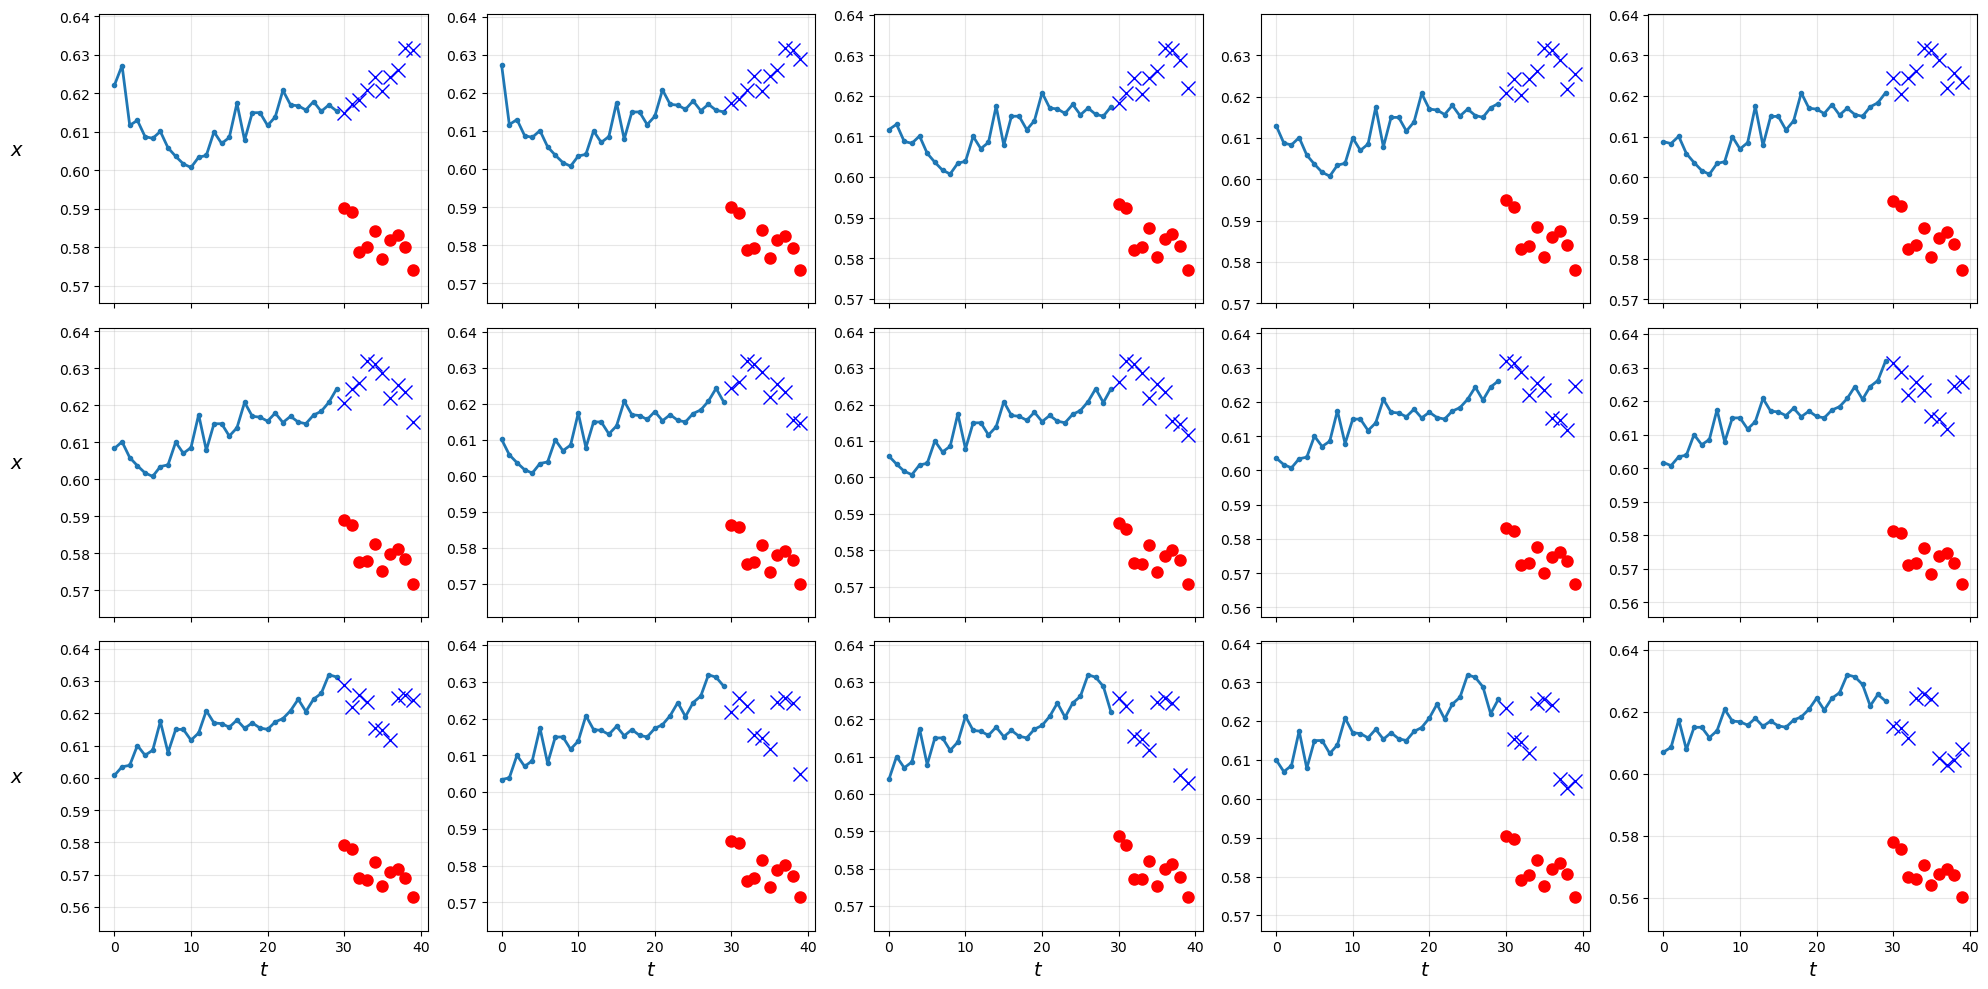


Resultados - Optimización en Todos los Timesteps (10 días):
  MSE (último timestep):  0.002970
  RMSE (último timestep): 0.054500
COMPARACIÓN: Enfoque Multi-Paso Directo vs. Todos los Timesteps
            Enfoque     MSE     RMSE
 Multi-Paso Directo 0.00216 0.046478
Todos los Timesteps 0.00297 0.054500


In [31]:
y_pred_all_ts = predict(rnn_all_ts, dataloader_ts['test']).cpu().numpy()

plot_series_forecast(X_test_ms, y_test_ms, y_pred_all_ts[:, -1, :])

y_test_ts_last = Y_test_ts[:, -1, :]
y_pred_all_ts_last = y_pred_all_ts[:, -1, :]

mse_all_ts = mean_squared_error(y_test_ts_last, y_pred_all_ts_last)
rmse_all_ts = np.sqrt(mse_all_ts)

print(f"\nResultados - Optimización en Todos los Timesteps (10 días):")
print(f"  MSE (último timestep):  {mse_all_ts:.6f}")
print(f"  RMSE (último timestep): {rmse_all_ts:.6f}")

print("COMPARACIÓN: Enfoque Multi-Paso Directo vs. Todos los Timesteps")
comparison_ms = pd.DataFrame({
    'Enfoque': ['Multi-Paso Directo', 'Todos los Timesteps'],
    'MSE': [mse_multi, mse_all_ts],
    'RMSE': [np.sqrt(mse_multi), rmse_all_ts]})
print(comparison_ms.to_string(index=False))


## Intervalos de Confianza usando Dropout

En predicciones de series temporales, no basta con dar un valor puntual; es importante proporcionar **intervalos de confianza** alrededor de la predicción. 

Un método eficaz es usar **Dropout durante la evaluación**. Normalmente Dropout se apaga en modo evaluación, pero si lo mantenemos activado, cada pasada produce una red diferente. Al hacer múltiples pasadas, podemos:
- Calcular la media de las predicciones (predicción final)
- Calcular la desviación estándar (indicador de incertidumbre)
- Construir intervalos de confianza alrededor de la predicción

In [32]:
rnn_dropout = DeepRNN(n_out=horizon, dropout=0.3, input_size=X_train_ms.shape[2])
print("DeepRNN con Dropout:")
print(rnn_dropout)

DeepRNN con Dropout:
DeepRNN(
  (rnn): RNN(5, 64, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


In [33]:
print("Entrenando DeepRNN con Dropout...")
fit(rnn_dropout, dataloader_ms, epochs=200, early_stopping=20)

d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Entrenando DeepRNN con Dropout...


loss 0.00046 val_loss 0.00370 acc 0.99813 val_acc 0.94169:  44%|████▍     | 88/200 [00:23<00:30,  3.69it/s]


In [34]:
def predict_with_dropout(model, dataloader, n_samples=50):
    preds_list = []
    for _ in range(n_samples):
        model.train()
        with torch.no_grad():
            preds = torch.tensor([]).to(device)
            for batch in dataloader:
                X = batch
                X = X.to(device)
                pred = model(X)
                preds = torch.cat([preds, pred])
            preds_list.append(preds.cpu().numpy())
    return np.array(preds_list)

print("Generando predicciones con múltiples muestras de Dropout (50 muestras)...")
y_preds_dropout = predict_with_dropout(rnn_dropout, dataloader_ms['test'], n_samples=50)

y_pred_mean = y_preds_dropout.mean(axis=0)
y_pred_std = y_preds_dropout.std(axis=0)
y_pred_lower = y_pred_mean - 1.96 * y_pred_std
y_pred_upper = y_pred_mean + 1.96 * y_pred_std

mse_dropout = mean_squared_error(y_test_ms, y_pred_mean)
print(f"\nMSE con Dropout (50 muestras): {mse_dropout:.6f}")

Generando predicciones con múltiples muestras de Dropout (50 muestras)...

MSE con Dropout (50 muestras): 0.006499


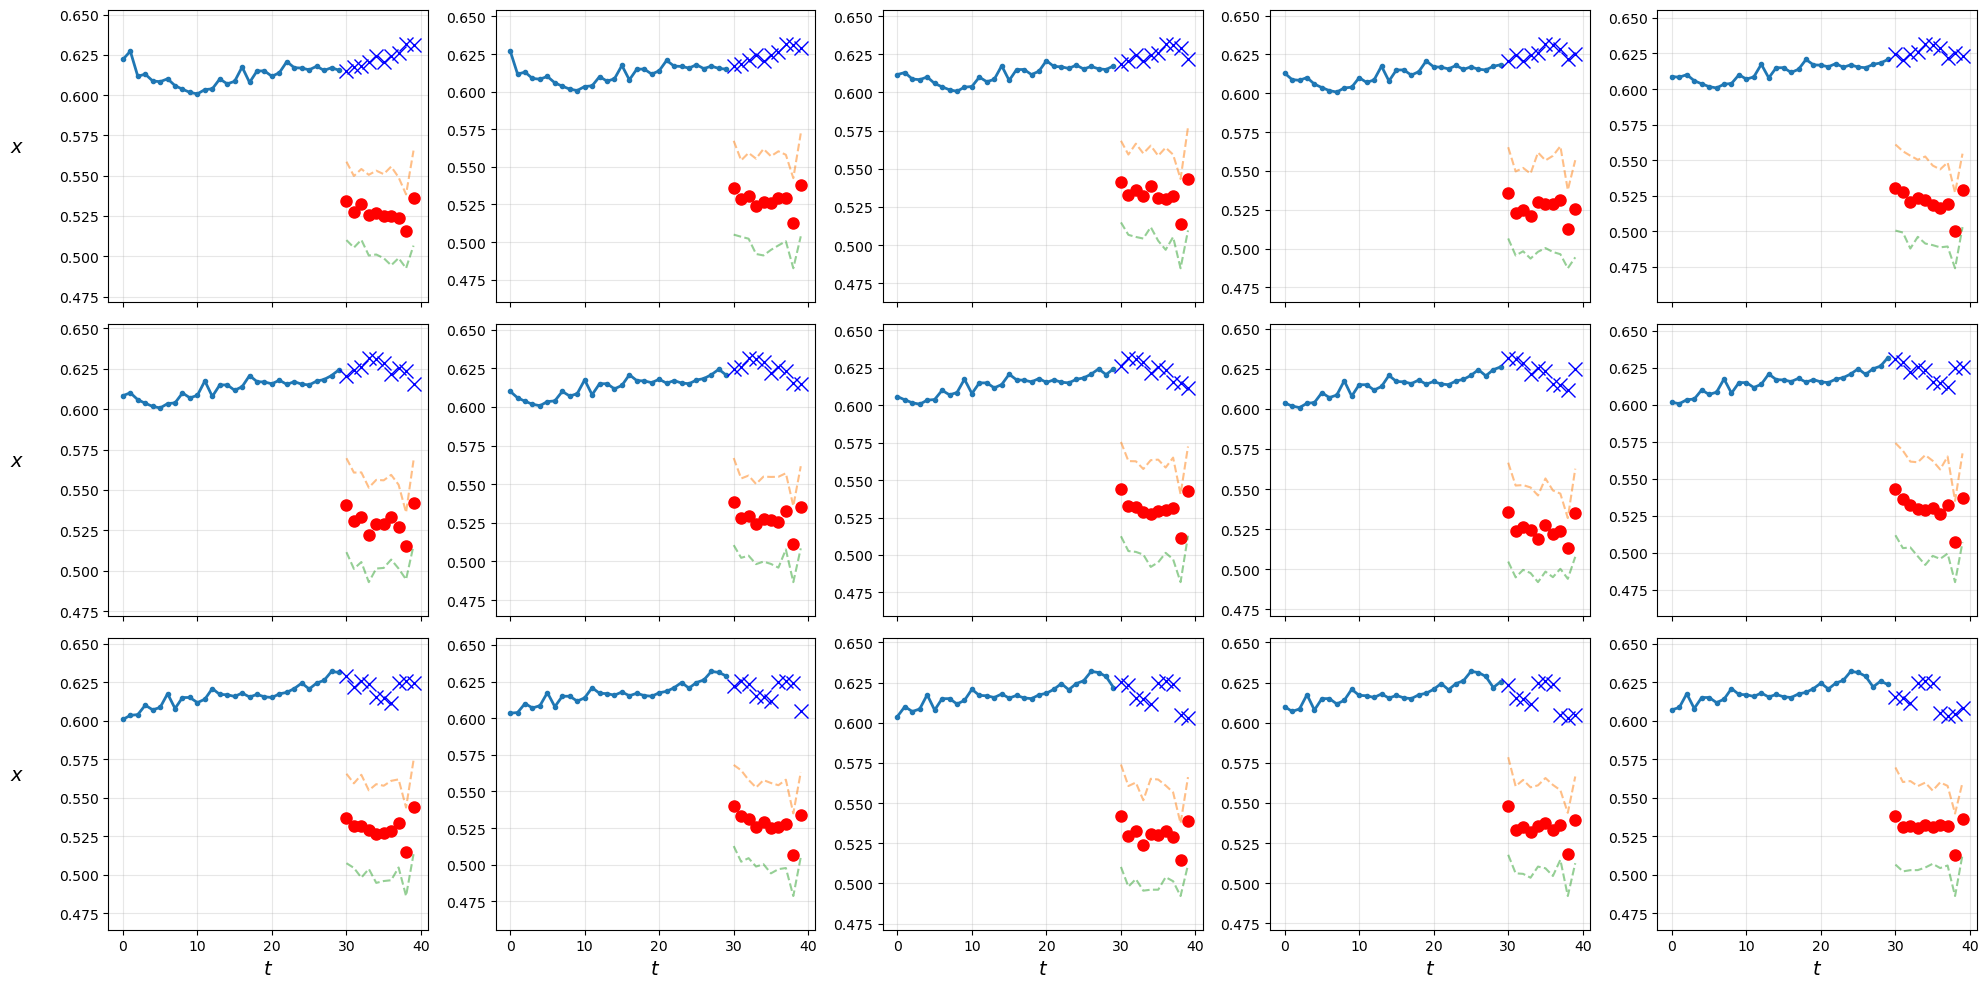

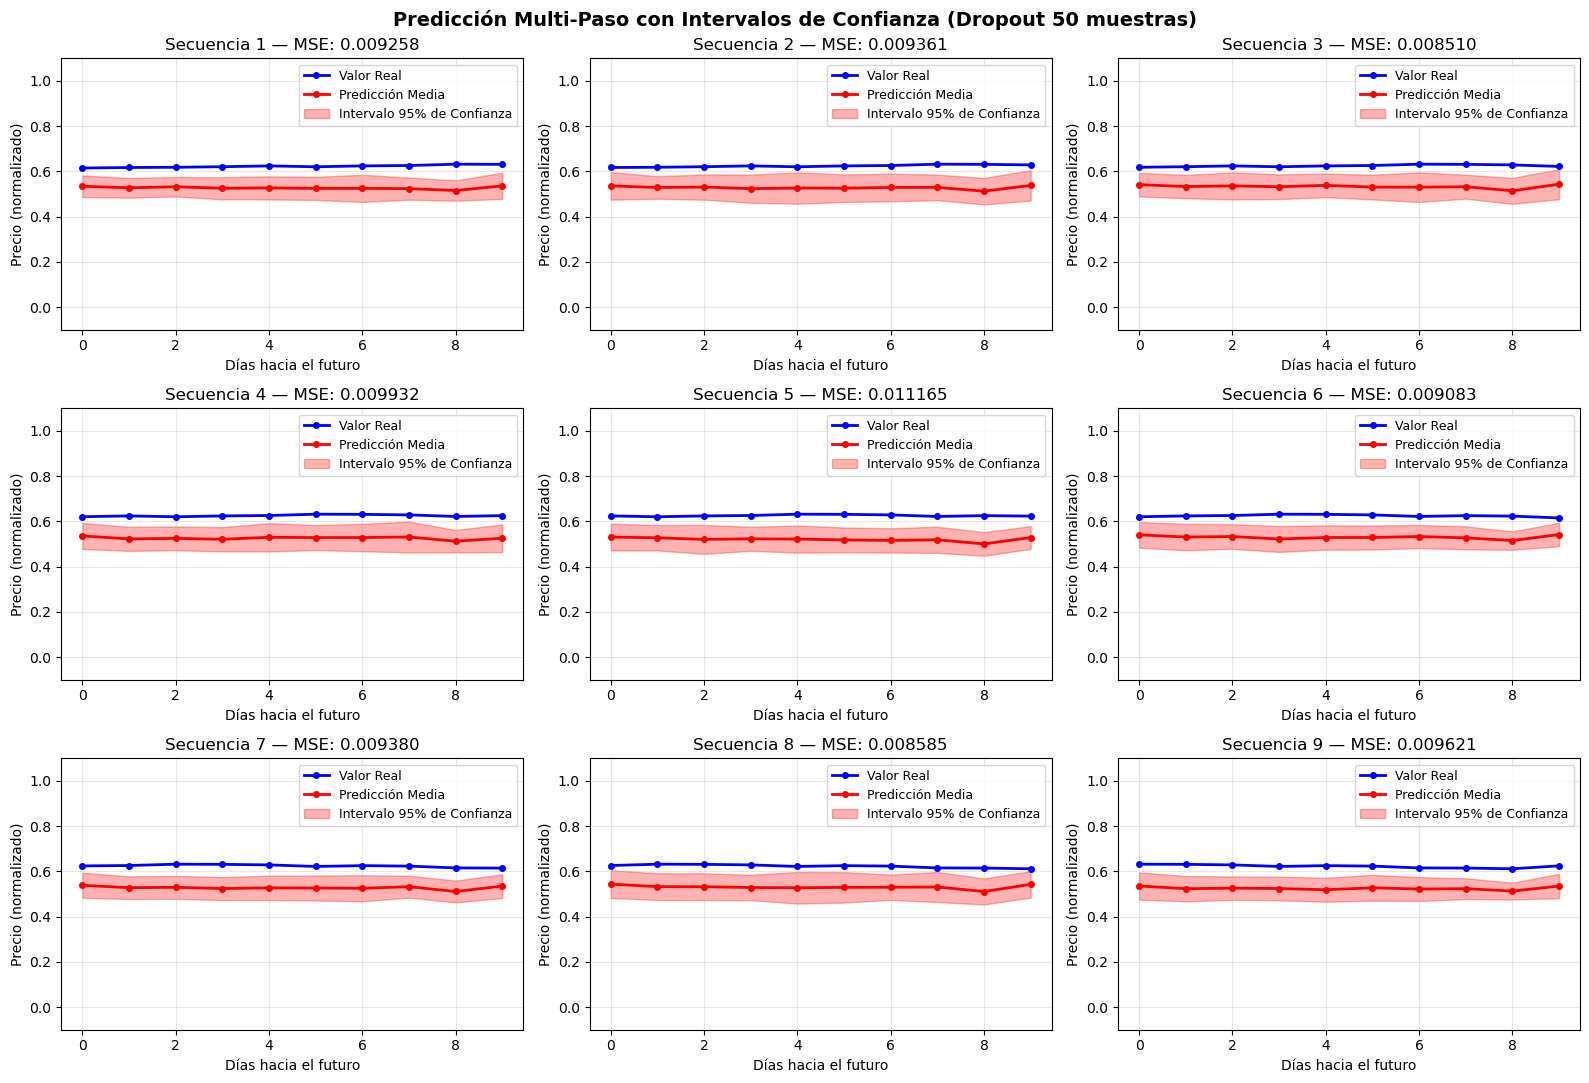

In [35]:
plot_series_forecast(X_test_ms, y_test_ms, y_pred_mean, y_pred_std)

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for i in range(9):
    axes[i].plot(y_test_ms[i], 'b.-', label='Valor Real', markersize=8, linewidth=2)
    axes[i].plot(y_pred_mean[i], 'r.-', label='Predicción Media', markersize=8, linewidth=2)
    
    axes[i].fill_between(range(horizon), y_pred_lower[i], y_pred_upper[i], 
                         alpha=0.3, color='red', label='Intervalo 95% de Confianza')
    
    axes[i].set_title(f'Secuencia {i+1} — MSE: {mean_squared_error(y_test_ms[i:i+1], y_pred_mean[i:i+1]):.6f}')
    axes[i].set_xlabel('Días hacia el futuro')
    axes[i].set_ylabel('Precio (normalizado)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='best', fontsize=9)
    axes[i].set_ylim(-0.1, 1.1)

fig.suptitle('Predicción Multi-Paso con Intervalos de Confianza (Dropout 50 muestras)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()